# Laboratorio: la forma de onda del circuito de van der Pol — guía del docente

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jfbonder/imc/blob/main/notebooks/docente/lab-vanderPol.ipynb)

> Versión con las soluciones completas. La versión para estudiantes, con esqueletos en lugar de las soluciones, es `notebooks/lab-vanderPol.ipynb`.

Este laboratorio cierra el segundo problema conductor de las notas: el circuito que oscila solo. La teoría respondió las preguntas 1 a 3: para $\lambda > 0$ el reposo es inestable (el circuito se *enciende*), la corriente termina sobre un único ciclo límite cuya amplitud y período no dependen del estado inicial (Teorema de Liénard), y en $\lambda = 0$ hay una bifurcación de Hopf degenerada (el ciclo aparece de golpe con amplitud $\approx 2$). Quedó pendiente la pregunta 4: **si medimos la corriente en un circuito real, ¿podemos determinar $\lambda$ y comprobar que el modelo predice la forma de onda?**

**Qué vamos a hacer.** Primero el *problema directo*: simular el sistema de van der Pol para varios $\lambda$, separar el régimen transitorio del permanente, medir el período y la amplitud del ciclo con **eventos** de `solve_ivp`, ver cómo la forma de onda pasa de sinusoidal a *oscilación de relajación* y mirar su **espectro** (cuántos armónicos tiene; un anticipo de la Parte II). Después el *problema inverso*: a partir de un registro de corriente con ruido, estimar $\lambda$ de dos maneras, por una **característica** del registro (el período, con una curva de calibración construida por simulación) y por **ajuste de la forma de onda completa** por mínimos cuadrados, y comparar cuál es más precisa y por qué.

**Lo que las notas no explican y este notebook sí.** Cómo se descarta un transitorio, cómo se usa un evento para medir un período, qué es un armónico y por qué una onda de relajación tiene muchos, cómo se construye y se invierte una curva de calibración, cómo se propaga el error de una medición a un parámetro, y el problema de la **fase** al ajustar una señal periódica (la solución no es una función de $t$ sino una familia de traslaciones). Mínimos cuadrados no lineales ya los usaron en el laboratorio del SIR; acá repasamos lo indispensable.

**Herramientas disponibles.** `scipy.integrate.solve_ivp` (`dense_output`, `events`, `t_eval`), `scipy.optimize.least_squares`, `numpy.fft`, `imc.estilo` (colores y figuras) e `imc.datos` (el registro está también en `datos/vanderpol_registro.csv`). Los notebooks `02-mecanicos` y `04-lyapunov-global` ya muestran el ciclo de van der Pol y su retrato de fase: acá no los repetimos, medimos.

**Cómo se evalúa.** La sección final de **interpretación escrita**. Cada tarea dice qué se espera y trae una celda de verificación. Tiempo estimado: una sesión de 4 h (la Tarea 7 es opcional).

In [1]:
# Configuración (funciona en Colab y en una copia local del repositorio)
try:
    import imc
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/jfbonder/imc.git"], check=True)
    import imc

import numpy as np
import matplotlib.pyplot as plt
from imc import estilo, datos
from imc.estilo import COLORES
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from imc.estilo import CICLO
estilo.activar()

## 1. El problema directo: transitorio, régimen permanente y forma de onda

El sistema es el de las notas (la ecuación de van der Pol escrita como sistema de primer orden),

$$\dot x = y,\qquad \dot y = -x - \lambda\,(x^2 - 1)\,y,$$

con $x$ la corriente (en unidades de $\sqrt{a/3b}$) y el tiempo en unidades de $\sqrt{LC}$, de modo que el período natural del circuito $LC$ es $2\pi$. Lo escribimos una vez, con la firma `F(t, X, *args)` de `solve_ivp`, y lo usamos en todo el laboratorio.

In [2]:
def vdP(t, X, lam):
    """Sistema de van der Pol: X = (x, y) con x la corriente e y = dx/dt."""
    x, y = X
    return [y, -x - lam * (x ** 2 - 1) * y]

### Transitorio y régimen permanente

Toda solución que no empiece en el origen converge al ciclo límite, pero *tarda*. La parte inicial de la solución, mientras todavía "recuerda" el dato inicial, es el **régimen transitorio**; lo que queda cuando ya está (a todos los efectos prácticos) sobre el ciclo es el **régimen permanente**. Amplitud, período, forma de onda y espectro son propiedades del régimen permanente: si los medimos sobre el transitorio, medimos cualquier cosa. En un experimento real es lo mismo: se enciende el circuito, se espera, y recién después se registra.

¿Cuánto hay que esperar? Cerca del reposo el sistema es aproximadamente lineal, con matriz $\begin{bmatrix}0&1\\-1&\lambda\end{bmatrix}$ y autovalores $\frac12(\lambda \pm \sqrt{\lambda^2-4})$: para $0 < \lambda < 2$ la corriente crece como $e^{\lambda t/2}$ mientras es chica. Partiendo de $x(0) = 0.01$, llegar a una amplitud de $1.5$ (tres cuartos de la final) lleva del orden de

$$t_{\rm enc} \approx \frac{2}{\lambda}\ln\frac{1.5}{0.01} = \frac{2\ln 150}{\lambda} \approx \frac{10}{\lambda},$$

que para $\lambda = 0.1$ son unas 100 unidades de tiempo (¡16 períodos!), y esa es una subestimación: en cuanto $|x|$ se acerca a $1$ la fricción deja de ser negativa en parte del ciclo y el crecimiento se frena. Para $\lambda$ grande el encendido es inmediato pero cada período dura del orden de $\lambda$, así que también hay que simular un tiempo proporcional a $\lambda$. Una receta práctica para este sistema: simular hasta $T_{\rm trans} = \max(60,\ 15\lambda,\ 40/\lambda)$ y tirar todo eso. La receta general, que sirve para cualquier sistema con un ciclo atractor: **comparar dos tramos consecutivos** (por ejemplo, los dos últimos períodos): si la amplitud o el período cambian entre uno y otro, todavía no llegaste.

Lo que vamos a hacer con `solve_ivp`: integrar el transitorio *sin* guardar nada (sin `t_eval` ni `dense_output`, que es lo más barato), quedarnos con el estado final `sol.y[:, -1]`, y arrancar desde ahí una segunda integración, ya en régimen permanente, con `dense_output=True` para poder evaluar $x(t)$ donde queramos. Usamos `rtol=1e-9, atol=1e-11`: el período lo vamos a medir con cuatro o cinco cifras y las tolerancias por defecto ($10^{-3}$) no alcanzan.

### Tarea 1: Simular hasta el régimen permanente y describir la forma de onda

Escribí:

* `simular(lam, X0=(0.01, 0.0), T=None, n=4000)`: integra desde `X0` hasta `T` (por defecto, `T = max(60, 15 * lam, 40 / lam) + 3 * (2 * np.pi + 2 * lam)`, es decir el transitorio y unos tres períodos más) con `dense_output=True` y devuelve `t, x, y` evaluados en `np.linspace(0, T, n)`.
* `t_encendido(t, x, umbral=1.5)`: el primer instante en que $|x|$ supera `umbral` (una medida del tiempo de encendido; el transitorio sigue un poco más, hasta que la amplitud llega a $2$).
* `permanente(lam, n_periodos=3, n=2000)`: integra el transitorio hasta $T_{\rm trans} = \max(60, 15\lambda, 40/\lambda)$ *sin* guardar la solución, y desde el estado final integra `n_periodos * (2 * np.pi + 2 * lam)` unidades más (una cota generosa del período, que vas a medir en la Tarea 2) con `dense_output=True`; devuelve `t, x, y` (con `t` desde $0$) evaluados en `n` puntos.

Después, para $\lambda = 0.1, 1, 5, 20$ (desde $(0.01, 0)$): una figura de cuatro filas y dos columnas; a la izquierda la simulación completa con `simular` (marcá $t_{\rm enc}$ con una línea vertical) y a la derecha el régimen permanente con `permanente`. Imprimí $t_{\rm enc}$ para cada $\lambda$ y, para $\lambda = 0.1$ y $1$, compará con $2\ln 150/\lambda$.

**Qué se espera.** Para $\lambda = 0.1$ un encendido lento (unas 100 unidades) y una onda que no se distingue de una sinusoide de amplitud $2$; para $\lambda = 1$ una sinusoide algo deformada; para $5$ y $20$ una **oscilación de relajación**: tramos lentos en los que $|x|$ baja despacio desde $\approx 2$ hasta $\approx 1$, separados por saltos casi verticales de $x \approx \pm 1$ a $x \approx \mp 2$, con un período mucho mayor que $2\pi$. La estimación $2\ln 150/\lambda$ tiene que andar bien para $\lambda = 0.1$ (a un 10 %) y peor para $\lambda = 1$ (¿por qué? pensá dónde deja de valer la aproximación lineal). Guardá para la interpretación una descripción de la forma de onda en cada caso.

lambda =   0.1: t_enc =  109.8   (2 ln 150 / lambda = 100.2)


lambda =   1.0: t_enc =   12.4   (2 ln 150 / lambda = 10.0)


lambda =   5.0: t_enc =    1.9


lambda =  20.0: t_enc =    0.7


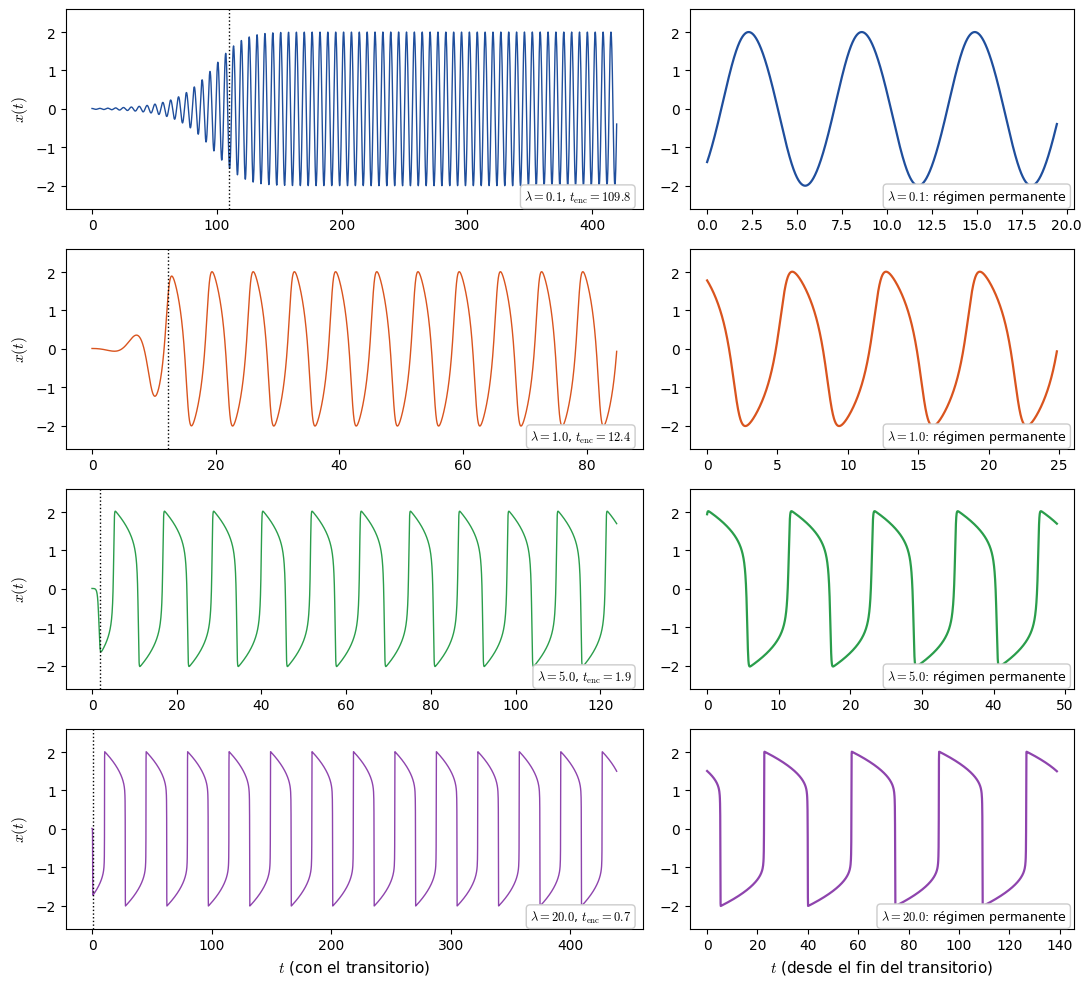

In [3]:
def simular(lam, X0=(0.01, 0.0), T=None, n=4000):
    """Solución desde X0 hasta T (transitorio incluido), evaluada en n puntos. Devuelve t, x, y."""
    if T is None:
        T = max(60, 15 * lam, 40 / lam) + 3 * (2 * np.pi + 2 * lam)
    sol = solve_ivp(vdP, (0, T), X0, args=(lam,), dense_output=True, rtol=1e-9, atol=1e-11)
    t = np.linspace(0, T, n)
    x, y = sol.sol(t)
    return t, x, y

def t_encendido(t, x, umbral=1.5):
    """Primer instante en que |x| supera el umbral."""
    k = np.argmax(np.abs(x) > umbral)
    return t[k]

def permanente(lam, n_periodos=3, n=2000):
    """Régimen permanente: integra el transitorio sin guardarlo y devuelve t, x, y de los n_periodos siguientes."""
    T_trans = max(60, 15 * lam, 40 / lam)
    s1 = solve_ivp(vdP, (0, T_trans), [0.01, 0.0], args=(lam,), rtol=1e-9, atol=1e-11)
    T = n_periodos * (2 * np.pi + 2 * lam)
    s2 = solve_ivp(vdP, (0, T), s1.y[:, -1], args=(lam,), dense_output=True, rtol=1e-9, atol=1e-11)
    t = np.linspace(0, T, n)
    x, y = s2.sol(t)
    return t, x, y

lams = [0.1, 1.0, 5.0, 20.0]
fig, axs = plt.subplots(4, 2, figsize=(11, 10), gridspec_kw={"width_ratios": [3, 2]})
for (ax1, ax2), lam, c in zip(axs, lams, CICLO):
    t, x, y = simular(lam)
    t_enc = t_encendido(t, x)
    ax1.plot(t, x, color=c, lw=1)
    ax1.axvline(t_enc, color="black", ls=":", lw=1)
    ax1.set_ylabel("$x(t)$"); ax1.set_ylim(-2.6, 2.6)
    estilo.parametros(ax1, rf"$\lambda = {lam}$, $t_{{\rm enc}} = {t_enc:.1f}$", loc="lower right")
    tp, xp, yp = permanente(lam)
    ax2.plot(tp, xp, color=c)
    ax2.set_ylim(-2.6, 2.6)
    estilo.parametros(ax2, rf"$\lambda = {lam}$: régimen permanente", loc="lower right")
    extra = f"   (2 ln 150 / lambda = {2 * np.log(150) / lam:.1f})" if lam <= 1 else ""
    print(f"lambda = {lam:5}: t_enc = {t_enc:6.1f}{extra}")
axs[-1, 0].set_xlabel("$t$ (con el transitorio)"); axs[-1, 1].set_xlabel("$t$ (desde el fin del transitorio)")
fig.tight_layout()

In [4]:
# Verificación
t, x, y = simular(0.1)
assert t.shape == x.shape == y.shape == (4000,) and t[0] == 0, "simular debe devolver t, x, y de n puntos desde t = 0"
te = t_encendido(t, x)
assert 90 < te < 130, f"t_enc para lambda = 0.1 debería ser ~110 (dio {te:.1f}): ¿integraste hasta T = 460?"
tp, xp, yp = permanente(5.0)
assert tp[0] == 0 and abs(np.abs(xp).max() - 2.02) < 0.05, "en régimen permanente la amplitud es ~2.02 para lambda = 5"
assert np.abs(xp[-500:]).max() > 1.9, "el tramo final de `permanente` no está en régimen permanente"
tp, xp, yp = permanente(0.1)
assert abs(np.abs(xp).max() - 2.0) < 0.02, "para lambda = 0.1 el transitorio es largo (~100): T_trans = 40 / lambda = 400"
print("simulación y régimen permanente: OK")

simulación y régimen permanente: OK


**Para el docente.** $t_{\rm enc}$ (umbral $1.5$): $\lambda = 0.1$: $109.8$ ($2\ln 150/\lambda = 100.2$); $\lambda = 1$: $12.4$ (estimación $10.0$: la aproximación lineal deja de valer en cuanto $|x| \sim 1$, donde la "fricción" cambia de signo; para $\lambda$ chico la amplitud crece según la ecuación promediada $\dot{\bar r} = \frac{\lambda}{8}\bar r(4 - \bar r^2)$ del ejercicio guiado, cuya solución da $t = \frac{2}{\lambda}[\ln(r/r_0) + \frac12\ln\frac{4 - r_0^2}{4 - r^2}]$, es decir $92$ para $\lambda = 0.1$ hasta $r = 1.5$: el $10\,\%$ restante es el error del promedio, porque $r$ no es exactamente la amplitud); $\lambda = 5$: $1.9$; $\lambda = 20$: $0.7$ (para $\lambda$ grande el origen es un nodo con autovalor rápido $\approx \lambda$ y la corriente salta a $\approx 2$ enseguida). Si se usa umbral $1.9$, los tiempos son bastante mayores ($129$ para $\lambda = 0.1$): la aproximación a la amplitud final es lenta, $4 - \bar r^2 \sim e^{-\lambda t}$. Error típico: usar `t_eval` en la primera integración de `permanente` y guardar miles de puntos inútiles, o (peor) hacer las dos integraciones desde $(0.01, 0)$. Tiempo: 30 minutos.

## 2. Medir el período y la amplitud con eventos

### Eventos en `solve_ivp`

Medir un período "a ojo" sobre la grilla de `t_eval` tiene un error del orden del paso de la grilla. `solve_ivp` sabe hacerlo mucho mejor: con `events=g`, donde `g(t, X, *args)` es una función escalar, el integrador detecta **cada instante en que $g$ cruza cero** y lo localiza con la precisión del integrador (resuelve $g(t, X(t)) = 0$ sobre su interpolante), no con la de la grilla. Devuelve los instantes en `sol.t_events[0]` y los estados en `sol.y_events[0]`. Dos atributos de la función controlan el comportamiento: `g.direction = 1` cuenta solo los cruces **ascendentes** ($g$ pasa de negativo a positivo; `-1` los descendentes, `0` todos) y `g.terminal = True` detiene la integración en el primero (acá no lo queremos: queremos varios cruces).

Para el período del ciclo, el evento natural es `g(t, X, lam) = X[0]` con `direction = 1`: los cruces ascendentes de $x$ por cero. Entre dos cruces consecutivos hay exactamente un período (¡con `direction = 0` habría medio período!). En régimen permanente, las diferencias `np.diff(sol.t_events[0])` tienen que ser todas iguales hasta la tolerancia del integrador: **esa es la verificación de que estás en régimen permanente**, y su promedio es el período $T(\lambda)$. La amplitud $A(\lambda)$ es el máximo de $|x|$ sobre un período (evaluado en una grilla fina con `sol.sol`).

### Una función que devuelve la forma de onda

Nos va a servir, tres veces en este laboratorio, tener la forma de onda de un período como una **función** en lugar de una tabla: `ciclo(lam)` devuelve el período $T$ y una función `f(s)` que vale $x$ en la fase $s$ (medida desde un cruce ascendente por cero), extendida periódicamente: `f(s) = sol.sol(t_a + (s mod T))[0]`, con $t_a$ el instante de un cruce. Con eso, el espectro (Tarea 3) se calcula muestreando `f` exactamente sobre un período, y el ajuste de la forma de onda (Tarea 6) evalúa `f(t - t0)` en los instantes del registro.

### Oscilaciones de relajación

Para $\lambda$ grande la ecuación $\ddot x + \lambda(x^2-1)\dot x + x = 0$ tiene dos escalas de tiempo. Escribiendo $\dot x = y$, $\dot y = -x - \lambda(x^2-1)y$: cuando $|x| > 1$ el término $-\lambda(x^2-1)y$ es una fricción enorme, y la trayectoria se pega a la curva donde $\dot y \approx 0$ (la nulclina de $y$, $y = -x/(\lambda(x^2-1))$, del ejercicio guiado) y la recorre **despacio**, con velocidad $|y| \sim 1/\lambda$: en esa fase $|x|$ baja desde $\approx 2$ hasta $1$. Al llegar a $|x| = 1$ la fricción se anula y cambia de signo, la nulclina se va al infinito y la trayectoria **salta** en un tiempo $O(1)$ (mucho menor que $\lambda$) hasta la otra rama, en $x \approx \mp 2$. El período es dos tramos lentos más dos saltos, y calculando el tiempo de los tramos lentos sobre la nulclina se obtiene el resultado asintótico (Van der Pol, 1926; lo citamos sin demostración)

$$T(\lambda) = (3 - 2\ln 2)\,\lambda + O(\lambda^{-1/3}) \approx 1.614\,\lambda \qquad (\lambda \to \infty),$$

mientras que la amplitud sigue siendo $\approx 2$ (el tramo lento arranca donde la nulclina tiene su extremo, en $x = \pm 2$ para $\lambda$ grande). Este es el mecanismo de una **oscilación de relajación**: acumulación lenta y descarga rápida, el mismo de un tubo de neón con un capacitor, de un grifo que gotea o del latido cardíaco en el modelo de van der Pol y van der Mark de 1928. Lo vamos a ver en la tabla: $T/\lambda$ tiende a $1.614$ por arriba (la corrección $O(\lambda^{-1/3})$ es positiva y decae lento; a $\lambda = 20$ todavía vale un 7 %).

### Tarea 2: Período y amplitud en función de λ

Escribí:

* `ciclo(lam)`: integra el transitorio como en `permanente`, y desde el estado final integra `4 * (2 * np.pi + 2 * lam)` unidades más con `dense_output=True` y el evento `cruce(t, X, lam) = X[0]` con `cruce.direction = 1`. Toma los dos últimos cruces $t_a < t_b$, define $T = t_b - t_a$ y devuelve `T, f` con `f(s) = sol.sol(t_a + np.mod(s, T))[0]` (una función que acepta arrays). Comprobá que las diferencias entre cruces consecutivos coinciden (a $10^{-6}$, digamos); si no, el transitorio no terminó.
* `periodo_amplitud(lam)`: usa `ciclo` y devuelve `T, A` con $A = \max|f(s)|$ sobre `s = np.linspace(0, T, 4000)`.

Después, sobre `lams_cal = np.geomspace(0.1, 20, 25)`, calculá `T_cal` y `A_cal` (guardalos: son la curva de calibración de la Tarea 5), imprimí una tabla con $\lambda$, $T$, $T/2\pi$, $T/\lambda$, $A$, y una figura con dos paneles: $T(\lambda)$ con las referencias $2\pi$ y $(3 - 2\ln 2)\lambda$ (eje $x$ logarítmico), y $A(\lambda)$ con la referencia $2$.

**Qué se espera.** $T(0.1) = 2\pi$ a tres cifras, $T$ creciente en $\lambda$ (¡importante para la Tarea 5!), $T/\lambda \to 1.61$ desde arriba ($T(20)/20 \approx 1.73$), y $A$ entre $2.00$ y $2.03$ para todo $\lambda$: la amplitud es prácticamente **insensible** a $\lambda$ (¿qué máximo tiene y en qué $\lambda$? anotalo). La tabla tarda unos segundos. Si algún $T$ sale la mitad de lo esperado, el evento está contando los dos sentidos de cruce.

 lambda        T   T/2pi  T/lambda       A
  0.100   6.2871  1.0006    62.871  2.0001
  0.125   6.2893  1.0010    50.434  2.0002
  0.156   6.2927  1.0015    40.465  2.0003
  0.194   6.2979  1.0023    32.477  2.0004
  0.242   6.3061  1.0036    26.077  2.0006
  0.302   6.3188  1.0057    20.953  2.0009
  0.376   6.3385  1.0088    16.855  2.0014
  0.469   6.3690  1.0137    13.581  2.0022
  0.585   6.4162  1.0212    10.972  2.0033
  0.729   6.4887  1.0327     8.898  2.0050
  0.909   6.5996  1.0504     7.257  2.0074
  1.134   6.7667  1.0769     5.967  2.0105
  1.414   7.0136  1.1162     4.959  2.0142
  1.764   7.3680  1.1727     4.178  2.0180
  2.199   7.8611  1.2511     3.574  2.0211
  2.742   8.5283  1.3573     3.110  2.0230
  3.420   9.4136  1.4982     2.753  2.0234
  4.265  10.5715  1.6825     2.479  2.0226
  5.318  12.0700  1.9210     2.270  2.0210
  6.632  13.9933  2.2271     2.110  2.0188
  8.270  16.4461  2.6175     1.989  2.0164
 10.313  19.5588  3.1129     1.896  2.0140
 12.861  23

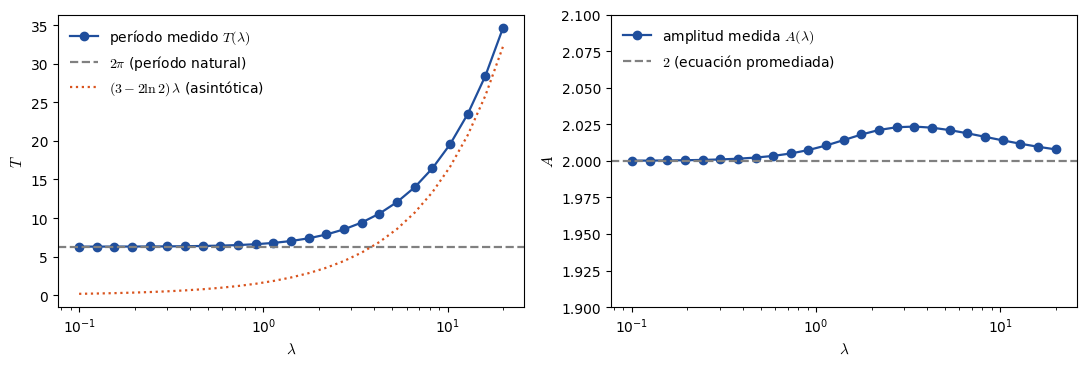

In [5]:
def cruce(t, X, lam):
    """Evento: cruce de x por cero (con direction = 1, sólo ascendentes)."""
    return X[0]
cruce.direction = 1

def ciclo(lam):
    """Régimen permanente de van der Pol: devuelve (T, f) con T el período y f(s) la forma de onda
    (x en función de la fase s medida desde un cruce ascendente por cero), extendida periódicamente."""
    T_trans = max(60, 15 * lam, 40 / lam)
    s1 = solve_ivp(vdP, (0, T_trans), [0.01, 0.0], args=(lam,), rtol=1e-9, atol=1e-11)
    sol = solve_ivp(vdP, (0, 4 * (2 * np.pi + 2 * lam)), s1.y[:, -1], args=(lam,), rtol=1e-9, atol=1e-11,
                    dense_output=True, events=cruce)
    te = sol.t_events[0]
    assert len(te) >= 3 and np.ptp(np.diff(te)) < 1e-6, f"lambda = {lam}: los períodos entre cruces no coinciden {np.diff(te)}"
    t_a, t_b = te[-2], te[-1]
    T = t_b - t_a
    def f(s):
        return sol.sol(t_a + np.mod(s, T))[0]
    return T, f

def periodo_amplitud(lam):
    """Período y amplitud (máximo de |x|) del ciclo límite."""
    T, f = ciclo(lam)
    return T, np.abs(f(np.linspace(0, T, 4000))).max()

lams_cal = np.geomspace(0.1, 20, 25)
TA = np.array([periodo_amplitud(lam) for lam in lams_cal])
T_cal, A_cal = TA[:, 0], TA[:, 1]
print(f"{'lambda':>7} {'T':>8} {'T/2pi':>7} {'T/lambda':>9} {'A':>7}")
for lam, T, A in zip(lams_cal, T_cal, A_cal):
    print(f"{lam:7.3f} {T:8.4f} {T / (2 * np.pi):7.4f} {T / lam:9.3f} {A:7.4f}")
print(f"máximo de A: {A_cal.max():.4f} en lambda = {lams_cal[A_cal.argmax()]:.2f};  (3 - 2 ln 2) = {3 - 2 * np.log(2):.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
ax1.plot(lams_cal, T_cal, "o-", color=COLORES["dato"], label="período medido $T(\\lambda)$")
ax1.axhline(2 * np.pi, color=COLORES["gris"], ls="--", label=r"$2\pi$ (período natural)")
ax1.plot(lams_cal, (3 - 2 * np.log(2)) * lams_cal, ":", color=COLORES["modelo"], label=r"$(3 - 2\ln 2)\,\lambda$ (asintótica)")
ax1.set_xscale("log"); ax1.set_xlabel(r"$\lambda$"); ax1.set_ylabel("$T$"); ax1.legend(loc="upper left")
ax2.plot(lams_cal, A_cal, "o-", color=COLORES["dato"], label="amplitud medida $A(\\lambda)$")
ax2.axhline(2, color=COLORES["gris"], ls="--", label="$2$ (ecuación promediada)")
ax2.set_xscale("log"); ax2.set_xlabel(r"$\lambda$"); ax2.set_ylabel("$A$"); ax2.set_ylim(1.9, 2.1); ax2.legend(loc="upper left")
fig.tight_layout()

In [6]:
# Verificación
T1, f1 = ciclo(1.0)
assert abs(T1 - 6.6633) < 2e-3, f"T(1) debería ser 6.663 (dio {T1:.4f}); con 3.33 el evento cuenta los dos sentidos"
assert abs(f1(0.0)) < 1e-6 and f1(0.01) > 0, "f(0) debe ser un cruce ascendente por cero"
assert np.allclose(f1(np.array([0.3, 0.3 + T1, 0.3 - T1])), f1(0.3)), "f debe ser periódica y aceptar arrays"
assert T_cal.shape == A_cal.shape == (25,)
assert abs(T_cal[0] - 2 * np.pi) < 0.01 and np.all(np.diff(T_cal) > 0), "T(0.1) ~ 2 pi y T creciente en lambda"
assert 1.65 < T_cal[-1] / 20 < 1.8, "T(20)/20 debería ser ~1.73"
assert np.all(np.abs(A_cal - 2.01) < 0.03), "la amplitud debería ser ~2.00-2.03 para todo lambda"
print("período y amplitud: OK")

período y amplitud: OK


**Para el docente.** Valores: $T(0.1) = 6.2844$, $T(1) = 6.6633$, $T(5) = 11.612$, $T(20) = 34.68$ ($T/\lambda = 1.734$; el término $O(\lambda^{-1/3})$ tiene coeficiente $\approx 7.01$: $32.27 + 7.01 \cdot 20^{-1/3} = 34.85$). Amplitud máxima $2.0234$ en $\lambda \approx 3$ (es muy chata entre $2.5$ y $4$); $A(0.1) = 2.0002$, $A(20) = 2.008$. Los errores típicos: contar los dos sentidos de cruce (período mitad), medir sobre el transitorio (para $\lambda = 0.1$ da amplitud $< 2$ si `T_trans` es 60), y olvidar `np.mod` en `f` (la función deja de ser periódica y `sol.sol` extrapola fuera del intervalo). La afirmación de las notas de que "el período crece como $\lambda$" se ve bien en la tabla; conviene remarcar que la asintótica converge lento. Tiempo: 40 minutos (con la lectura sobre relajación).

## 3. El espectro de la forma de onda (anticipo de la Parte II)

Una señal periódica de período $T$ se puede escribir como suma de sinusoides de frecuencias múltiplos de la **fundamental** $1/T$:

$$x(t) = a_0 + \sum_{k \ge 1} A_k \cos\!\Bigl(\frac{2\pi k\,t}{T} + \varphi_k\Bigr).$$

Es la **serie de Fourier** de $x$, que la Parte II desarrolla con cuidado; acá solo la usamos como descripción. El término $k$ es el **$k$-ésimo armónico** (el primero es la fundamental), y el conjunto de amplitudes $A_k$ es el **espectro** de la señal. Una sinusoide pura tiene un solo armónico. Cuanto más se aparte la forma de onda de una sinusoide (esquinas, saltos, tramos planos), más armónicos hacen falta para describirla: un salto casi vertical necesita muchas sinusoides de frecuencia alta que se sumen constructivamente en el instante del salto. Eso es exactamente lo que le pasa a la onda de relajación.

**Cómo se calcula con `numpy.fft`.** Si muestreamos $x$ en $N$ puntos equiespaciados sobre **exactamente un período**, $x_j = x(jT/N)$, entonces `X = np.fft.rfft(x)` devuelve los coeficientes $X_k = \sum_j x_j e^{-2\pi i jk/N}$ para $k = 0, \dots, N/2$, y la amplitud del armónico $k$ es $A_k = 2|X_k|/N$ (y $a_0 = |X_0|/N$). La condición "exactamente un período" es la que hace que cada armónico caiga en un único índice $k$; si la ventana no es un múltiplo del período, la energía de cada armónico se desparrama en los índices vecinos (*fuga espectral*; en la Parte II van a ver cómo se maneja). Como tenemos `f` de la Tarea 2 con el período exacto, acá no hay fuga.

**Una simetría.** El sistema de van der Pol es invariante por $(x, y) \mapsto (-x, -y)$, y el ciclo límite es único, así que el ciclo es simétrico respecto del origen y la forma de onda cumple $x(t + T/2) = -x(t)$. Una señal con esa propiedad tiene **solo armónicos impares** (los pares se cancelan: es un buen ejercicio de la Parte II). Verificalo en el espectro: los $A_k$ con $k$ par tienen que ser cero hasta el redondeo.

### Tarea 3: Espectro para λ = 0.1 y λ = 5

Escribí `espectro_ciclo(lam, N=1024)` que use `ciclo(lam)`, muestree `f` en `s = np.arange(N) * T / N` y devuelva `k, A` con `k = 0, ..., N//2` y $A_k$ como arriba. Para $\lambda = 0.1$ y $\lambda = 5$:

1. Imprimí $A_1$ y las amplitudes relativas $A_k/A_1$ para $k = 2, \dots, 9$, y el número de armónicos **apreciables**, `n_apreciables`: los $k \ge 1$ con $A_k/A_1 > 0.01$ (1 % de la fundamental).
2. Una figura con dos paneles (uno por $\lambda$) con el espectro como barras (`ax.stem` o `ax.bar`) hasta $k = 30$, en escala logarítmica en $y$ (`ax.set_yscale("log")`, con un piso de $10^{-6}$ para los ceros).

**Qué se espera.** Para $\lambda = 0.1$, la fundamental con amplitud $2.000$ y un tercer armónico de un 1.2 % (compatible con $\lambda/8$: la primera corrección a la sinusoide es proporcional a $\lambda$), nada más apreciable; para $\lambda = 5$, la fundamental con amplitud algo mayor que $2$ (¿por qué puede ser $A_1 > \max|x|$? pensá en la onda cuadrada) y una decena de armónicos impares apreciables, que decaen lentamente. Los armónicos pares, cero en los dos casos. Anotá `n_apreciables` para los dos $\lambda$: es el número que resume "cuán no sinusoidal" es la onda.

lambda = 0.1: A_1 = 2.0002;  A_k / A_1 para k = 2..9: [0.     0.0125 0.     0.0003 0.     0.     0.     0.    ]
   armónicos apreciables (> 1 % de la fundamental): 2;  mayor armónico par: 6.1e-12


lambda = 5.0: A_1 = 2.1061;  A_k / A_1 para k = 2..9: [0.     0.2773 0.     0.1455 0.     0.091  0.     0.0618]
   armónicos apreciables (> 1 % de la fundamental): 11;  mayor armónico par: 1.8e-15


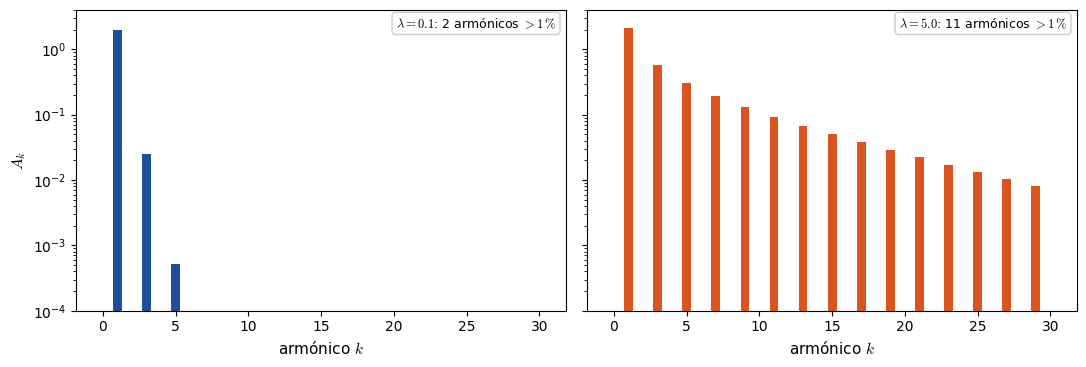

In [7]:
def espectro_ciclo(lam, N=1024):
    """Amplitudes A_k (k = 0..N//2) de los armónicos de la forma de onda en régimen permanente."""
    T, f = ciclo(lam)
    x = f(np.arange(N) * T / N)
    X = np.fft.rfft(x)
    A = 2 * np.abs(X) / N
    A[0] = np.abs(X[0]) / N
    return np.arange(len(A)), A

n_apreciables = {}
fig, axs = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, lam, c in zip(axs, [0.1, 5.0], CICLO):
    k, A = espectro_ciclo(lam)
    rel = A / A[1]
    n_apreciables[lam] = int(np.sum(rel[1:] > 0.01))
    print(f"lambda = {lam}: A_1 = {A[1]:.4f};  A_k / A_1 para k = 2..9: {np.array2string(rel[2:10], precision=4, suppress_small=True)}")
    print(f"   armónicos apreciables (> 1 % de la fundamental): {n_apreciables[lam]};  mayor armónico par: {rel[2::2].max():.1e}")
    ax.bar(k[:31], np.maximum(A[:31], 1e-6), color=c, width=0.6)
    ax.set_yscale("log"); ax.set_ylim(1e-4, 4); ax.set_xlabel("armónico $k$")
    estilo.parametros(ax, rf"$\lambda = {lam}$: {n_apreciables[lam]} armónicos $> 1\,\%$", loc="upper right")
axs[0].set_ylabel("$A_k$")
fig.tight_layout()

In [8]:
# Verificación
k, A = espectro_ciclo(0.1)
assert A.shape == (513,) and abs(A[1] - 2.0) < 0.005, "A_1 para lambda = 0.1 debería ser 2.000"
assert A[2::2].max() < 1e-6 * A[1], "los armónicos pares deberían ser nulos (simetría x(t + T/2) = -x(t))"
assert abs(A[3] / A[1] - 0.0125) < 0.002, "el tercer armónico de lambda = 0.1 debería ser ~1.25 % de la fundamental"
assert n_apreciables[0.1] == 2 and 9 <= n_apreciables[5.0] <= 13, f"armónicos apreciables: {n_apreciables} (se esperaba 2 y ~11)"
print("espectro: OK")

espectro: OK


**Para el docente.** $\lambda = 0.1$: $A_1 = 2.0002$, $A_3/A_1 = 0.0125$ (la solución perturbativa es $x \approx 2\cos t + \lambda(\tfrac34\sin t - \tfrac14\sin 3t)$, de donde $A_3/A_1 = \lambda/8$), $A_5/A_1 = 3\cdot10^{-4}$: 2 armónicos apreciables. $\lambda = 5$: $A_1 = 2.106 > 2.02 = \max|x|$ (como en la onda cuadrada, cuya fundamental es $4/\pi$ veces la altura), $A_3/A_1 = 0.277$, $A_5/A_1 = 0.146$, $A_7/A_1 = 0.091$, $A_9/A_1 = 0.062$, 11 armónicos apreciables (hasta $k = 21$); para $\lambda = 20$ serían 32. Armónicos pares $< 10^{-10}$. Si alguien muestrea con `np.linspace(0, T, N)` (que incluye los dos extremos: $N - 1$ intervalos), aparecen armónicos pares chicos y fuga: es la ocasión de explicar la condición "exactamente un período". Tiempo: 30 minutos.

## 4. El problema inverso: estimar $\lambda$ a partir de un registro con ruido

Hasta acá, dado $\lambda$ calculamos la forma de onda (**problema directo**). La pregunta 4 del problema conductor es la inversa: dado un registro de la corriente de un circuito real, ¿cuánto vale $\lambda$? Un registro real es una lista de valores $x_j$ medidos en instantes $t_j = j\,\Delta t$ (un osciloscopio digital), con **ruido** de medición, y en régimen permanente (el circuito está encendido desde hace rato). No sabemos en qué fase del ciclo empezó la grabación.

No tenemos un circuito, así que el registro es sintético: la celda siguiente lo genera con un $\lambda$ que **no tienen que mirar** (está dentro de `_registro_secreto`; el objetivo es estimarlo, y al final lo comparan con la respuesta del docente). La misma serie está en `datos/vanderpol_registro.csv`. Lo que sí sabemos: el registro dura 60 unidades de tiempo, con paso $\Delta t = 0.02$ (3001 muestras), y el ruido es aditivo, de media cero y de tamaño desconocido.

Dos estrategias, que son las dos formas generales de resolver un problema inverso con un modelo de simulación:

**(a) Por características.** Extraer del registro un número que dependa de $\lambda$ (una *característica*: el período, la amplitud, la proporción de armónicos, la pendiente de los saltos...) y, con el modelo, calcular esa misma característica para muchos $\lambda$: una **curva de calibración** $T(\lambda)$. Estimar $\lambda$ es invertir la curva: buscar el $\lambda$ cuyo $T(\lambda)$ coincide con el $T$ medido. Requiere que la curva sea **monótona** (si no, la inversa no es única) y que la característica sea **sensible** a $\lambda$: un error $\delta T$ en la medición se convierte en un error

$$\delta\lambda \approx \frac{\delta T}{T'(\lambda)}$$

en el parámetro (es la regla de propagación de errores de primer orden, la "delta method" de Estadística). Si $T'(\lambda)$ es chico, el error se amplifica. Por eso la amplitud, que la Tarea 2 mostró que es $\approx 2$ para todo $\lambda$ ($A'(\lambda) \approx 0$), **no sirve** para estimar $\lambda$: cualquier error de medición se convierte en un error enorme del parámetro. Tampoco sirve la característica más obvia del registro, su tamaño.

**(b) Por ajuste de la forma de onda completa.** Usar *todos* los datos: buscar el $\lambda$ que hace que la forma de onda simulada, $x(t;\lambda)$, esté lo más cerca posible del registro en el sentido de mínimos cuadrados, $\sum_j (x(t_j;\lambda) - x_j)^2$. Es lo que hicieron con el SIR, con dos diferencias. Primera: el modelo no es una solución con dato inicial conocido sino **una órbita periódica**, que solo está definida a menos de una traslación temporal: la fase en la que arrancó la grabación es un parámetro más, $t_0$, y lo que se ajusta es $x(t;\lambda, t_0) = f_\lambda(t - t_0)$ con $f_\lambda$ la función de la Tarea 2. Segunda: la función de costo en $\lambda$ es **muy no convexa**. Si el $\lambda$ de prueba tiene un período un poco distinto del verdadero, la simulación y el registro se van desfasando a lo largo de las 60 unidades (siete períodos): coinciden al principio, se oponen a mitad de camino, vuelven a coincidir... y el costo tiene un mínimo local cada vez que se "recupera" un período. Por eso el ajuste **necesita un buen punto de partida**, y el punto de partida natural es la estimación (a). Lo mismo con $t_0$: se lo inicializa con el primer cruce ascendente por cero del registro, para que la fase inicial esté cerca de la correcta.

**Cuál es mejor.** La estrategia (a) usa un solo número extraído de los datos (y desecha el resto); la (b) usa los 3001. Si el modelo es correcto, (b) tiene que ser más precisa, y la incertidumbre de $\hat\lambda$ se puede estimar como en el SIR, con la jacobiana en el óptimo: $\operatorname{Var}(\hat p) \approx \hat\sigma^2 (J^\top J)^{-1}$, $\hat\sigma^2 = \|r\|^2/(n - 2)$. Pero (a) tiene ventajas: es más robusta (no necesita punto de partida, no tiene mínimos locales), es más barata y, sobre todo, **no supone que el modelo es correcto en todos sus detalles**: si el circuito real tiene una pequeña asimetría o un ruido no gaussiano, el período sigue siendo un dato confiable mientras que el ajuste de la forma completa se contamina. En la práctica se hace (a) primero y (b) después, partiendo de (a).

**Suavizar antes de medir.** Los cruces por cero de una señal con ruido son un desastre: cerca de cada cruce verdadero el ruido produce varios cruces espurios. La solución más simple es un **promedio móvil** de $m$ muestras, `np.convolve(x, np.ones(m) / m, mode="same")`, con $m$ tal que la ventana $m\,\Delta t$ sea mucho menor que el período y mayor que la escala del ruido: acá $m = 11$ (ventana $0.22$, contra un período de varias unidades) alcanza. (Con `mode="same"` los primeros y últimos $m/2$ valores promedian con ceros y no valen; es visible en los bordes del gráfico y no molesta para los cruces.) El promedio móvil sesga un poco la forma (redondea los saltos) y puede desplazar un poco *todos* los cruces por igual (si la onda no es simétrica alrededor del cruce), pero no las diferencias entre cruces, que es lo que mide el período. Aun así, con mucho ruido sobreviven cruces espurios; el remedio es usar lo que sabemos del modelo: **el período del ciclo es mayor que $2\pi$ para todo $\lambda$** (Tarea 2), así que dos cruces ascendentes a menos de $2\pi$ no pueden ser verdaderos los dos, y nos quedamos con el primero de cada grupo. La amplitud, en cambio, no tiene arreglo: el máximo de una señal con ruido está sesgado hacia arriba (al pico se le suma el máximo del ruido) y el suavizado lo sesga hacia abajo (promedia el pico con sus vecinos): otra razón para no usarla.

In [9]:
def _registro_secreto():
    """Registro sintético de corriente: NO MIRAR el valor de lambda (es lo que hay que estimar).
    Simula el circuito en régimen permanente, lo muestrea con paso dt y le suma ruido gaussiano."""
    lam_oculto, sigma, dt, T_reg = 2.7, 0.1, 0.02, 60.0
    rng = np.random.default_rng(20260929)
    s1 = solve_ivp(vdP, (0, 100), [0.01, 0.0], args=(lam_oculto,), rtol=1e-9, atol=1e-11)     # transitorio
    t = np.arange(0, T_reg + dt / 2, dt)
    s2 = solve_ivp(vdP, (0, T_reg), s1.y[:, -1], args=(lam_oculto,), rtol=1e-9, atol=1e-11, t_eval=t)
    return t, s2.y[0] + sigma * rng.standard_normal(len(t))

t_r, x_r = _registro_secreto()
dt_r = t_r[1] - t_r[0]
print(f"registro: {len(t_r)} muestras, paso dt = {dt_r}, duración {t_r[-1]:.0f} (en unidades de sqrt(LC))")
# La misma serie está en el repositorio: datos.obtener("vanderpol_registro.csv"), columnas t, x

registro: 3001 muestras, paso dt = 0.02, duración 60 (en unidades de sqrt(LC))


### Tarea 4: El registro: graficar, suavizar y medir el período a mano

Con `t_r, x_r`:

1. Graficá el registro completo y, en un segundo panel, un tramo de un período aproximado (las primeras 10 unidades) para ver el ruido.
2. Escribí `suavizar(x, m=11)` (promedio móvil con `np.convolve(..., mode="same")`) y `cruces_ascendentes(t, x, sep_min=2 * np.pi)` que devuelva los instantes en que `x` pasa de negativo a no negativo, **interpolando linealmente** entre las dos muestras (índices `i` con `x[i] < 0 <= x[i+1]`; el cruce está en `t[i] - x[i] * (t[i+1] - t[i]) / (x[i+1] - x[i])`) y descartando todo cruce que esté a menos de `sep_min` del último aceptado (el período es siempre mayor que $2\pi$: ver la Sección 4).
3. Con los cruces `tc` del registro suavizado, estimá el período como `T_reg = (tc[-1] - tc[0]) / (len(tc) - 1)` (la pendiente de la recta $t_c$ contra número de cruce, que aprovecha todos los cruces) y su incertidumbre `dT_reg = np.diff(tc).std(ddof=1) / np.sqrt(len(tc) - 1)`. Estimá también la amplitud `A_reg` como el máximo de $|x|$ suavizado. Imprimí los tres y el número de cruces. Marcá los cruces en la figura.

**Qué se espera.** Entre 6 y 8 cruces ascendentes limpios (si aparecen decenas, no suavizaste o el promedio es muy corto), un período entre $6.3$ y $35$ (la tabla de la Tarea 2 te dice en qué rango de $\lambda$ estás), una incertidumbre $\delta T$ del orden de la centésima, y una amplitud cercana a $2$ (que no te dice nada sobre $\lambda$). Mirá la forma de onda del registro y ubicala entre las de la Tarea 1: ¿sinusoide deformada u onda de relajación?

cruces ascendentes del registro suavizado: 7  (sin suavizar ni separación mínima: 15)
períodos entre cruces: [8.476 8.464 8.479 8.49  8.46  8.475]
T_reg = 8.4742 ± 0.0044   (T / 2 pi = 1.349);  A_reg = 2.099


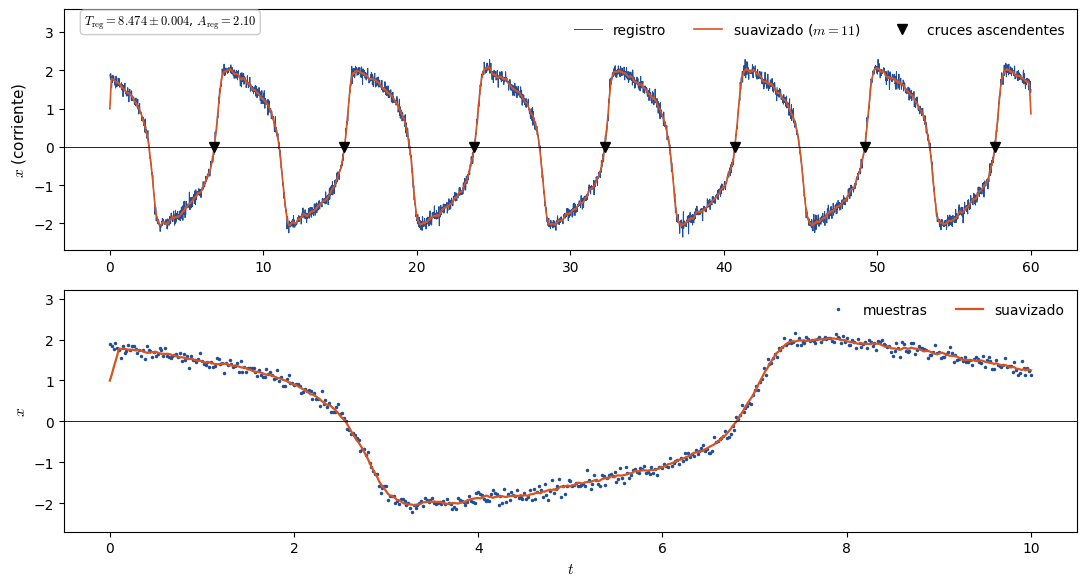

In [10]:
def suavizar(x, m=11):
    """Promedio móvil de m muestras (mode="same": misma longitud que x)."""
    return np.convolve(x, np.ones(m) / m, mode="same")

def cruces_ascendentes(t, x, sep_min=2 * np.pi):
    """Instantes de cruce de x por cero de negativo a positivo, interpolando linealmente;
    se descarta todo cruce a menos de sep_min del último aceptado."""
    i = np.where((x[:-1] < 0) & (x[1:] >= 0))[0]
    tc_todos = t[i] - x[i] * (t[i + 1] - t[i]) / (x[i + 1] - x[i])
    tc = []
    for c in tc_todos:
        if not tc or c - tc[-1] >= sep_min:
            tc.append(c)
    return np.array(tc)

x_s = suavizar(x_r)
tc = cruces_ascendentes(t_r, x_s)
T_reg = (tc[-1] - tc[0]) / (len(tc) - 1)
dT_reg = np.diff(tc).std(ddof=1) / np.sqrt(len(tc) - 1)
A_reg = np.abs(x_s).max()
print(f"cruces ascendentes del registro suavizado: {len(tc)}  (sin suavizar ni separación mínima: {len(cruces_ascendentes(t_r, x_r, sep_min=0))})")
print(f"períodos entre cruces: {np.round(np.diff(tc), 3)}")
print(f"T_reg = {T_reg:.4f} ± {dT_reg:.4f}   (T / 2 pi = {T_reg / (2 * np.pi):.3f});  A_reg = {A_reg:.3f}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6))
ax1.plot(t_r, x_r, color=COLORES["dato"], lw=0.7, label="registro")
ax1.plot(t_r, x_s, color=COLORES["modelo"], lw=1.2, label="suavizado ($m = 11$)")
ax1.plot(tc, np.zeros_like(tc), "v", color="black", ms=7, label="cruces ascendentes")
ax1.axhline(0, color="black", lw=0.6); ax1.set_ylim(-2.7, 3.6); ax1.set_ylabel("$x$ (corriente)"); ax1.legend(loc="upper right", ncol=3)
estilo.parametros(ax1, rf"$T_{{\rm reg}} = {T_reg:.3f} \pm {dT_reg:.3f}$, $A_{{\rm reg}} = {A_reg:.2f}$", loc="upper left")
sel = t_r <= 10
ax2.plot(t_r[sel], x_r[sel], ".", color=COLORES["dato"], ms=3, label="muestras")
ax2.plot(t_r[sel], x_s[sel], color=COLORES["modelo"], label="suavizado")
ax2.axhline(0, color="black", lw=0.6); ax2.set_ylim(-2.7, 3.2); ax2.set_xlabel("$t$"); ax2.set_ylabel("$x$"); ax2.legend(loc="upper right", ncol=2)
fig.tight_layout()

In [11]:
# Verificación
assert np.allclose(suavizar(np.ones(50)) [10:40], 1), "suavizar debe conservar una constante (lejos de los bordes)"
tc_chk = cruces_ascendentes(np.array([0., 1., 2., 3.]), np.array([-1., -0.5, 0.5, 1.]))
assert np.allclose(tc_chk, [1.5]), "cruces_ascendentes: el cruce de (-0.5, 0.5) entre t = 1 y 2 está en 1.5"
t_chk = np.arange(0, 16, 0.1)
tc_chk = cruces_ascendentes(t_chk, np.sin(t_chk - 0.5) + 0.4 * np.sin(20 * t_chk))
assert len(tc_chk) == 3 and np.allclose(tc_chk, [0.5, 0.5 + 2 * np.pi, 0.5 + 4 * np.pi], atol=0.4), "la separación mínima debe eliminar los cruces espurios"
assert 5 <= len(tc) <= 9, f"{len(tc)} cruces: se esperaban entre 5 y 9 (¿suavizaste?)"
assert 6 < T_reg < 36 and dT_reg < 0.05, f"T_reg = {T_reg:.3f} ± {dT_reg:.3f}: fuera de lo esperado"
assert abs(A_reg - 2) < 0.3
print(f"registro: {len(tc)} cruces, T_reg = {T_reg:.3f}: OK")

registro: 7 cruces, T_reg = 8.474: OK


**Para el docente.** El registro tiene $\lambda = 2.7$, $\sigma = 0.1$, $\Delta t = 0.02$, 60 unidades (≈ 7 períodos), semilla `20260929`. Sin suavizar ni separación mínima hay 15 cruces ascendentes; suavizado, 7, en $t \approx 6.80, 15.28, 23.74, 32.22, 40.71, 49.17, 57.65$; $T_{\rm reg} = 8.474 \pm 0.004$ (verdadero: $T(2.7) = 8.4745$); $A_{\rm reg} = 2.10$ (el máximo del ruido suavizado, $\approx 0.1$, se suma al pico). La forma es intermedia: ya se ven los tramos lentos y los saltos, pero no verticales. Tiempo: 25 minutos.

### Tarea 5: Estimación por la curva de calibración

Con `lams_cal, T_cal` de la Tarea 2:

1. Verificá que `T_cal` es creciente e invertí la curva por interpolación lineal: `lam_cal = np.interp(T_reg, T_cal, lams_cal)` (¡`np.interp` necesita el primer array creciente: por eso el orden de los argumentos!). La grilla tiene solo 25 puntos, así que hay un **error de interpolación**: medilo calculando el período verdadero de `lam_cal` con `periodo_amplitud` y comparándolo con `T_reg`; la diferencia, dividida por $T'(\lambda)$, es la corrección que le falta a `lam_cal` (un paso de Newton). Aplicala y comprobá que ahora $T(\hat\lambda)$ coincide con $T_{\rm reg}$ a $10^{-3}$.
2. Propagá el error: calculá $T'(\lambda)$ en `lam_cal` con `np.gradient(T_cal, lams_cal)` interpolado (sirve también para el paso de Newton del ítem 1), y `dlam_cal = dT_reg / T'`. Hacé lo mismo, solo para ver el número, con la amplitud: `dA = 0.02` (un error optimista de medición) dividido por $|A'(\lambda)|$.
3. Figura: la curva de calibración con el punto $(\hat\lambda, T_{\rm reg})$ y las líneas que lo proyectan sobre los ejes.

**Qué se espera.** Una corrección de Newton comparable a $\delta\lambda$ o menor (si es mucho mayor, la grilla es demasiado gruesa cerca de tu $\lambda$), un $\hat\lambda$ con dos cifras confiables ($\delta\lambda$ de unas milésimas) y un $\delta\lambda$ "por amplitud" absurdo (de orden 1 o mayor): la amplitud no identifica $\lambda$. Anotá $\hat\lambda \pm \delta\lambda$ para compararlo en la Tarea 6.

interpolación lineal: lambda = 2.6984, cuyo período verdadero es 8.4725 (T_reg = 8.4742)
corrección de Newton: +0.0013  ->  lambda por calibración: 2.6997 (T = 8.4742)
T'(lambda) = 1.256  ->  delta lambda = 0.0044 / 1.256 = 0.0035
A'(lambda) = 0.0024  ->  con delta A = 0.02, delta lambda = 8.2  (la amplitud no identifica lambda)


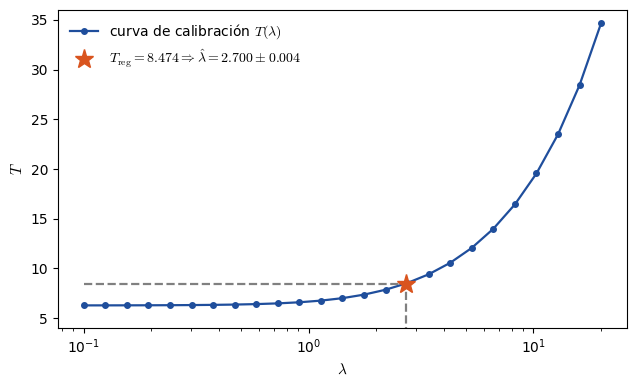

In [12]:
assert np.all(np.diff(T_cal) > 0), "T(lambda) debe ser creciente para poder invertirla"
lam_interp = np.interp(T_reg, T_cal, lams_cal)
dTdlam = np.interp(lam_interp, lams_cal, np.gradient(T_cal, lams_cal))
T_interp = periodo_amplitud(lam_interp)[0]
lam_cal = lam_interp + (T_reg - T_interp) / dTdlam          # un paso de Newton corrige el error de interpolación
T_check = periodo_amplitud(lam_cal)[0]
dAdlam = np.interp(lam_cal, lams_cal, np.gradient(A_cal, lams_cal))
dlam_cal = dT_reg / dTdlam
dlam_por_amplitud = 0.02 / abs(dAdlam)
print(f"interpolación lineal: lambda = {lam_interp:.4f}, cuyo período verdadero es {T_interp:.4f} (T_reg = {T_reg:.4f})")
print(f"corrección de Newton: {(T_reg - T_interp) / dTdlam:+.4f}  ->  lambda por calibración: {lam_cal:.4f} (T = {T_check:.4f})")
print(f"T'(lambda) = {dTdlam:.3f}  ->  delta lambda = {dT_reg:.4f} / {dTdlam:.3f} = {dlam_cal:.4f}")
print(f"A'(lambda) = {dAdlam:.4f}  ->  con delta A = 0.02, delta lambda = {dlam_por_amplitud:.1f}  (la amplitud no identifica lambda)")

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(lams_cal, T_cal, "o-", color=COLORES["dato"], ms=4, label="curva de calibración $T(\\lambda)$")
ax.plot([lams_cal[0], lam_cal, lam_cal], [T_reg, T_reg, 4], "--", color=COLORES["gris"])
ax.plot(lam_cal, T_reg, "*", color=COLORES["modelo"], ms=14, label=rf"$T_{{\rm reg}} = {T_reg:.3f} \Rightarrow \hat\lambda = {lam_cal:.3f} \pm {dlam_cal:.3f}$")
ax.set_xscale("log"); ax.set_ylim(4, 36); ax.set_xlabel(r"$\lambda$"); ax.set_ylabel("$T$"); ax.legend(loc="upper left")
fig.tight_layout()

In [13]:
# Verificación
assert abs(T_check - T_reg) < 1e-3, "después de la corrección, T(lam_cal) debería coincidir con T_reg a 1e-3"
assert abs(lam_cal - lam_interp) < 0.05, "la corrección de Newton debería ser chica (grilla razonable)"
assert 0.5 < lam_cal < 15, f"lambda por calibración = {lam_cal:.3f}: fuera del rango razonable (¿T_reg correcto?)"
assert 0 < dlam_cal < 0.05, f"delta lambda = {dlam_cal:.4f}: se esperaban unas centésimas o menos"
assert dlam_por_amplitud > 0.5, "el error por amplitud tiene que ser enorme"
print(f"calibración: lambda = {lam_cal:.3f} ± {dlam_cal:.3f}: OK")

calibración: lambda = 2.700 ± 0.004: OK


**Para el docente.** Interpolación lineal: $2.6984$, con período verdadero $8.4726$ contra $T_{\rm reg} = 8.4742$: corrección $+0.0013$, $\hat\lambda_{\rm cal} = 2.6997$; $T'(2.7) \approx 1.26$, $\delta\lambda = 0.0035$. (El error de interpolación es comparable a $\delta\lambda$ porque $T(\lambda)$ es convexa y la grilla geométrica tiene paso $0.55$ ahí; si hacen la grilla lineal en $[0.1, 20]$ con 25 puntos, el paso es $0.83$ y la corrección es mayor.) Por amplitud: $A'(2.7) \approx 0.002$ (estamos casi en el máximo de $A(\lambda)$: el peor caso posible), $\delta\lambda \approx 8$. Tiempo: 20 minutos.

### Tarea 6: Estimación por ajuste de la forma de onda completa

Escribí:

* `x_modelo(t, lam, t0)`: `T, f = ciclo(lam)` y devuelve `f(t - t0)` (la forma de onda de $\lambda$ desfasada para que su cruce ascendente por cero caiga en $t_0$).
* `residuos(p, t, x)` con `p = (lam, t0)`: `x_modelo(t, *p) - x`.

Después:

1. Ajustá con `least_squares(residuos, [lam_cal, tc[0]], args=(t_r, x_r), bounds=([0.05, tc[0] - 3], [30, tc[0] + 3]))` (cada evaluación de los residuos cuesta dos `solve_ivp`: el ajuste tarda unos segundos). Guardá `ajuste` y `lam_aj, t0_aj = ajuste.x`. Imprimí $\hat\lambda$, $\hat t_0$, el error estándar de cada uno (con $\hat\sigma^2 (J^\top J)^{-1}$, $\hat\sigma^2 = \|r\|^2/(n-2)$) y $\hat\sigma$, que es tu estimación del **tamaño del ruido** del registro.
2. Repetí el ajuste partiendo de $\lambda = 1$ (mismo $t_0$ inicial) en `ajuste_malo` y compará `cost` y $\hat\lambda$.
3. Para entender el ítem 2: calculá el costo $C(\lambda) = \sum_j r_j^2$ con $t_0$ fijo en `t0_aj` sobre `np.linspace(1, 6, 60)` y graficalo (eje $y$ logarítmico). Guardá en `minimos` los $\lambda$ de la grilla donde $C$ tiene un mínimo local. ¿Cuántos hay? ¿Dónde está el global?
4. Figura con dos paneles: el registro y la forma de onda ajustada (un tramo de 20 unidades), y los residuos $r_j$ en función de $t$.

**Qué se espera.** Un $\hat\lambda$ que coincide con el de calibración a dos cifras pero con un error estándar unas diez veces menor, $\hat\sigma \approx$ el tamaño del ruido que veías a ojo en la Tarea 4, residuos sin estructura (ruido blanco: si ves una oscilación en los residuos, el período ajustado está apenas mal o el modelo no describe la forma). Desde $\lambda = 1$ el optimizador se queda en un mínimo local con un costo cientos de veces mayor: el gráfico de $C(\lambda)$ tiene que mostrar el mínimo global en $\hat\lambda$ y varios mínimos locales a los costados, uno por cada período que se "pierde" en 60 unidades.

`ftol` termination condition is satisfied. (3 evaluaciones)
ajuste: lambda = 2.6996 ± 0.0005,  t0 = 6.8052 ± 0.0020,  ruido estimado sigma = 0.0998
calibración: lambda = 2.6997 ± 0.0035  ->  el ajuste es 7 veces más preciso


desde lambda = 1: lambda = 1.4313, cost = 5104.1  (desde la calibración: cost = 14.9)


mínimos locales de C(lambda) con t0 fijo, en la grilla: [1.51 2.69 4.14 5.15 5.83]


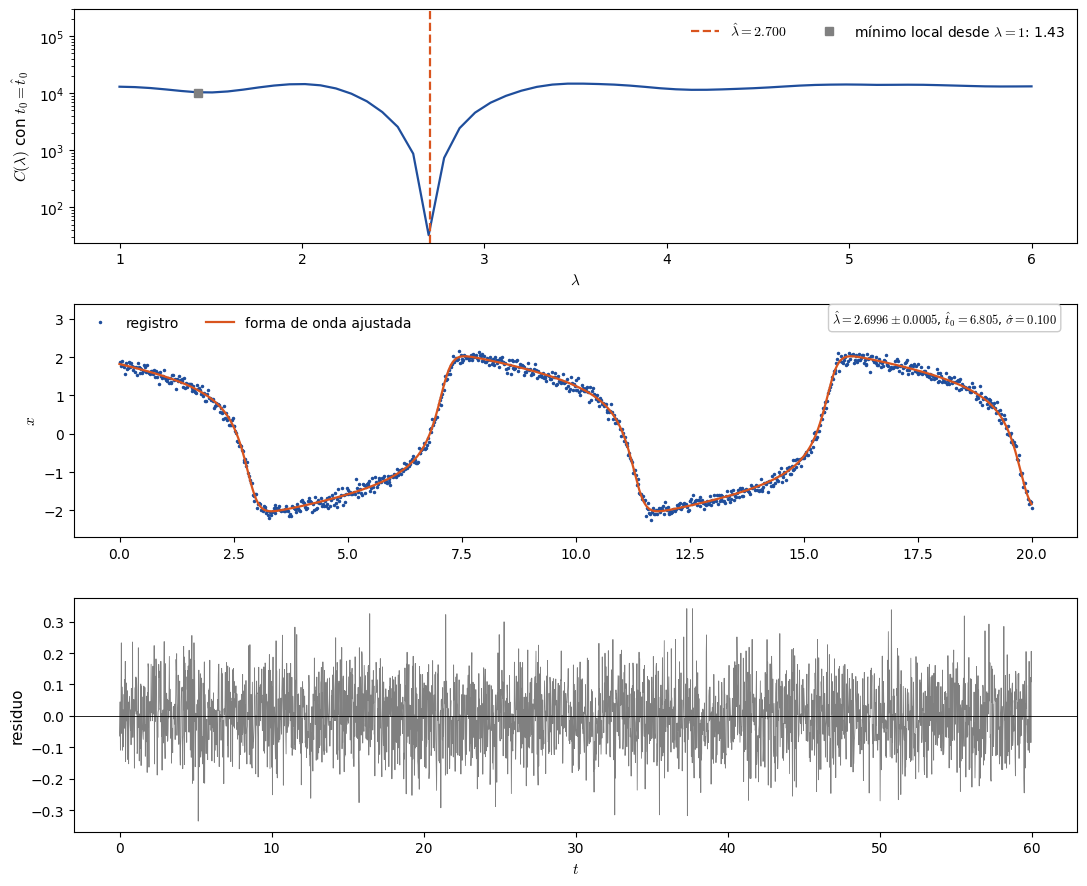

In [14]:
def x_modelo(t, lam, t0):
    """Forma de onda del ciclo de lambda, desfasada: cruce ascendente por cero en t = t0."""
    T, f = ciclo(lam)
    return f(t - t0)

def residuos(p, t, x):
    """Residuos x_modelo(t; lam, t0) - x, con p = (lam, t0)."""
    return x_modelo(t, *p) - x

p0 = [lam_cal, tc[0]]
cotas = ([0.05, tc[0] - 3], [30, tc[0] + 3])
ajuste = least_squares(residuos, p0, args=(t_r, x_r), bounds=cotas)
lam_aj, t0_aj = ajuste.x
n = len(t_r)
sigma2 = np.sum(ajuste.fun ** 2) / (n - 2)
cov = sigma2 * np.linalg.inv(ajuste.jac.T @ ajuste.jac)
se_lam, se_t0 = np.sqrt(np.diag(cov))
sigma_hat = np.sqrt(sigma2)
print(ajuste.message, f"({ajuste.nfev} evaluaciones)")
print(f"ajuste: lambda = {lam_aj:.4f} ± {se_lam:.4f},  t0 = {t0_aj:.4f} ± {se_t0:.4f},  ruido estimado sigma = {sigma_hat:.4f}")
print(f"calibración: lambda = {lam_cal:.4f} ± {dlam_cal:.4f}  ->  el ajuste es {dlam_cal / se_lam:.0f} veces más preciso")

ajuste_malo = least_squares(residuos, [1.0, tc[0]], args=(t_r, x_r), bounds=cotas)
print(f"desde lambda = 1: lambda = {ajuste_malo.x[0]:.4f}, cost = {ajuste_malo.cost:.1f}  (desde la calibración: cost = {ajuste.cost:.1f})")

lams_C = np.linspace(1, 6, 60)
C = np.array([np.sum(residuos([lam, t0_aj], t_r, x_r) ** 2) for lam in lams_C])
minimos = lams_C[1:-1][(C[1:-1] < C[:-2]) & (C[1:-1] < C[2:])]
print(f"mínimos locales de C(lambda) con t0 fijo, en la grilla: {np.round(minimos, 2)}")

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(11, 9))
ax1.semilogy(lams_C, C, "-", color=COLORES["dato"])
ax1.axvline(lam_aj, color=COLORES["modelo"], ls="--", label=rf"$\hat\lambda = {lam_aj:.3f}$")
ax1.plot(ajuste_malo.x[0], 2 * ajuste_malo.cost, "s", color=COLORES["gris"], label=rf"mínimo local desde $\lambda = 1$: {ajuste_malo.x[0]:.2f}")
ax1.set_ylim(top=3e5); ax1.set_xlabel(r"$\lambda$"); ax1.set_ylabel(r"$C(\lambda)$ con $t_0 = \hat t_0$"); ax1.legend(loc="upper right", ncol=2)
sel = t_r <= 20
ax2.plot(t_r[sel], x_r[sel], ".", color=COLORES["dato"], ms=3, label="registro")
ax2.plot(t_r[sel], x_modelo(t_r[sel], lam_aj, t0_aj), color=COLORES["modelo"], label="forma de onda ajustada")
ax2.set_ylim(-2.7, 3.4); ax2.set_ylabel("$x$"); ax2.legend(loc="upper left", ncol=2)
estilo.parametros(ax2, rf"$\hat\lambda = {lam_aj:.4f} \pm {se_lam:.4f}$, $\hat t_0 = {t0_aj:.3f}$, $\hat\sigma = {sigma_hat:.3f}$", loc="upper right")
ax3.plot(t_r, ajuste.fun, lw=0.6, color=COLORES["gris"])
ax3.axhline(0, color="black", lw=0.6); ax3.set_xlabel("$t$"); ax3.set_ylabel("residuo")
fig.tight_layout()

In [15]:
# Verificación
assert ajuste.success and abs(lam_aj - lam_cal) < 0.05, "el ajuste debería coincidir con la calibración a dos cifras"
assert se_lam < 0.3 * dlam_cal, "el error estándar del ajuste debería ser bastante menor que el de la calibración"
assert 0.05 < sigma_hat < 0.2, f"ruido estimado {sigma_hat:.3f}: fuera de lo esperado"
assert ajuste_malo.cost > 20 * ajuste.cost, "desde lambda = 1 el optimizador debería quedar en un mínimo local"
assert abs(np.mean(ajuste.fun)) < 0.01 and len(minimos) >= 3, "residuos con media ~0 y varios mínimos locales de C"
print(f"ajuste de la forma de onda: lambda = {lam_aj:.4f} ± {se_lam:.4f}: OK")

ajuste de la forma de onda: lambda = 2.6996 ± 0.0005: OK


In [16]:
# Solo en la guía del docente: el valor oculto
import inspect, re
lam_oculto = float(re.search(r"lam_oculto, sigma, dt, T_reg = ([0-9.]+)", inspect.getsource(_registro_secreto)).group(1))
print(f"lambda oculto = {lam_oculto};  calibración: {lam_cal:.4f} ± {dlam_cal:.4f} (error {lam_cal - lam_oculto:+.4f});  "
      f"ajuste: {lam_aj:.4f} ± {se_lam:.4f} (error {lam_aj - lam_oculto:+.4f})")

lambda oculto = 2.7;  calibración: 2.6997 ± 0.0035 (error -0.0003);  ajuste: 2.6996 ± 0.0005 (error -0.0004)


**Para el docente.** $\hat\lambda_{\rm aj} = 2.6996 \pm 0.0005$, $\hat t_0 = 6.805 \pm 0.002$, $\hat\sigma = 0.0998$ (verdadero: $0.1$); calibración $2.6997 \pm 0.0035$: el ajuste es unas 7 veces más preciso, como corresponde a usar 3001 datos en lugar de 7 cruces (y los dos aciertan: el verdadero es $2.7$). Desde $\lambda = 1$ el optimizador termina en $\lambda \approx 1.43$ con `cost` $\approx 5100$ contra $15$. $C(\lambda)$ con $t_0$ fijo tiene mínimos locales aproximadamente cada vez que $60/T(\lambda)$ cambia en una unidad (en la grilla de 60 puntos: $\lambda \approx 1.5, 2.7, 4.1, 5.2, 5.8$). Cada evaluación de `residuos` cuesta dos `solve_ivp`; el ajuste toma 4 a 6 evaluaciones (más las diferencias finitas), unos 3 s; la curva $C(\lambda)$, unos 10 s. Si alguien ajusta sin $t_0$ (fijando el cruce en `tc[0]`) obtiene casi lo mismo, porque `tc[0]` está a $0.002$ del verdadero: vale la pena que prueben qué pasa si `t0` se inicializa en $0$ (con las cotas de $\pm 3$ falla; sin cotas en $t_0$ el optimizador encuentra $t_0 = -1.67 \equiv 6.805 \pmod T$). Tiempo: 45 minutos.

## 5. (Opcional) Sensibilidad: más ruido, menos datos

Las dos estrategias tienen distinta **sensibilidad** al ruido y a la longitud del registro, y la manera de estudiarla es la de siempre en un problema inverso: generar registros sintéticos con un $\lambda$ *conocido* y ver cómo se comporta cada estimador. Para eso escribí un generador público, `registro_sintetico(lam, sigma, T_reg, semilla)`, con la misma receta que el secreto (transitorio de 100 unidades, `t_eval` con paso $0.02$, ruido gaussiano), y una función `estimar(t, x)` que aplique las dos estrategias (calibración y ajuste desde la calibración) y devuelva `lam_cal, dlam_cal, lam_aj, se_lam`. Cuando la calibración no sea posible (menos de dos cruces) el ajuste necesita otro punto de partida: una **búsqueda en grilla** del costo $C(\lambda)$ sobre `lams_cal` (con $t_0$ en el primer cruce) y arrancar del mejor; es más caro (25 evaluaciones) pero no depende de medir el período.

### Tarea 7: Sensibilidad de las dos estrategias

Con $\lambda = 3$ (conocido), estudiá:

1. **Ruido:** $\sigma = 0.1, 0.5, 1.0$ con $T_{\rm reg} = 60$ (con $\sigma = 1$ el ruido es la mitad de la amplitud: mirá cuántos cruces quedan con y sin la separación mínima).
2. **Longitud:** $T_{\rm reg} = 60, 20, 10$ con $\sigma = 0.1$ (con 10 unidades hay un solo período completo: ¿cuántos cruces quedan? ¿alcanza para la calibración? ¿y para el ajuste?).

Imprimí una tabla con el error real $\hat\lambda - 3$ y el error estimado ($\delta\lambda$ o error estándar) de cada estrategia en cada caso.

**Qué se espera.** El ajuste de la forma de onda degrada suavemente con el ruido (su error crece linealmente con $\sigma$: con $\sigma = 1$ todavía da $\lambda$ a la centésima) y con la falta de datos (como $1/\sqrt{n}$); la calibración por cruces se degrada más rápido con el ruido (los cruces se corren) y se rompe con registros cortos: con 20 unidades quedan dos cruces (un período, sin estimación de $\delta T$) y con 10 queda uno (no hay período), mientras que el ajuste, con la búsqueda en grilla, sigue funcionando porque un solo período de la forma de onda ya determina $\lambda$. Los errores estimados tienen que ser del orden de los errores reales (si el error real es 10 veces el estimado, algo está mal en la estimación). Escribí en una línea qué estrategia elegirías para un registro corto y ruidoso, y cuál si sospechás que el modelo no es exacto.

In [17]:
def registro_sintetico(lam, sigma=0.1, T_reg=60.0, semilla=0, dt=0.02):
    """Registro de corriente en régimen permanente con ruido gaussiano de desvío sigma."""
    rng = np.random.default_rng(semilla)
    s1 = solve_ivp(vdP, (0, 100), [0.01, 0.0], args=(lam,), rtol=1e-9, atol=1e-11)
    t = np.arange(0, T_reg + dt / 2, dt)
    s2 = solve_ivp(vdP, (0, T_reg), s1.y[:, -1], args=(lam,), rtol=1e-9, atol=1e-11, t_eval=t)
    return t, s2.y[0] + sigma * rng.standard_normal(len(t))

def estimar(t, x, m=11):
    """Devuelve lam_cal, dlam_cal, lam_aj, se_lam para el registro (t, x) (nan donde no se pueda)."""
    tc = cruces_ascendentes(t, suavizar(x, m))
    lam_c = dlam_c = np.nan
    if len(tc) >= 2:
        T = (tc[-1] - tc[0]) / (len(tc) - 1)
        lam_c = np.interp(T, T_cal, lams_cal)
        if len(tc) >= 3:
            dT = np.diff(tc).std(ddof=1) / np.sqrt(len(tc) - 1)
            dlam_c = dT / np.interp(lam_c, lams_cal, np.gradient(T_cal, lams_cal))
    if np.isfinite(lam_c):
        lam_0 = lam_c
    else:                                   # sin período: búsqueda en grilla del costo
        C_grilla = [np.sum(residuos([lam, tc[0]], t, x) ** 2) for lam in lams_cal]
        lam_0 = lams_cal[np.argmin(C_grilla)]
    aj = least_squares(residuos, [lam_0, tc[0]], args=(t, x), bounds=([0.05, tc[0] - 3], [30, tc[0] + 3]))
    s2 = np.sum(aj.fun ** 2) / (len(t) - 2)
    se = np.sqrt(np.diag(s2 * np.linalg.inv(aj.jac.T @ aj.jac)))[0]
    return lam_c, dlam_c, aj.x[0], se

lam_v = 3.0
casos = [(0.1, 60), (0.5, 60), (1.0, 60), (0.1, 20), (0.1, 10)]
print(f"{'sigma':>6} {'T_reg':>6} | {'calibración':>22} | {'ajuste':>22}")
print(f"{'':>6} {'':>6} | {'error real':>10} {'estimado':>10} | {'error real':>10} {'estimado':>10}")
for sigma, T_reg_v in casos:
    t, x = registro_sintetico(lam_v, sigma, T_reg_v, semilla=1)
    lc, dlc, la, sla = estimar(t, x)
    n_c = len(cruces_ascendentes(t, suavizar(x)))
    print(f"{sigma:6.1f} {T_reg_v:6.0f} | {lc - lam_v:+10.4f} {dlc:10.4f} | {la - lam_v:+10.4f} {sla:10.4f}   ({n_c} cruces)")

 sigma  T_reg |            calibración |                 ajuste
              | error real   estimado | error real   estimado


   0.1     60 |    -0.0044     0.0048 |    +0.0007     0.0005   (7 cruces)


   0.5     60 |    -0.0060     0.0292 |    +0.0033     0.0025   (7 cruces)


   1.0     60 |    -0.0099     0.0707 |    +0.0065     0.0049   (7 cruces)


   0.1     20 |    -0.0114        nan |    -0.0051     0.0028   (2 cruces)


   0.1     10 |       +nan        nan |    -0.0120     0.0086   (1 cruces)


In [18]:
# Verificación
t_chk, x_chk = registro_sintetico(3.0, 0.1, 60, semilla=1)
assert t_chk.shape == x_chk.shape == (3001,) and abs(np.std(x_chk) - 1.5) < 0.2
lc, dlc, la, sla = estimar(t_chk, x_chk)
assert abs(lc - 3) < 0.05 and abs(la - 3) < 0.01 and sla < dlc, "con sigma = 0.1 y 60 unidades las dos estrategias aciertan, el ajuste mejor"
t_chk, x_chk = registro_sintetico(3.0, 1.0, 60, semilla=1)
lc, dlc, la, sla = estimar(t_chk, x_chk)
assert abs(la - 3) < 0.05, "con sigma = 1 el ajuste debería seguir dando lambda a la centésima"
t_chk, x_chk = registro_sintetico(3.0, 0.1, 10, semilla=1)
lc, dlc, la, sla = estimar(t_chk, x_chk)
assert np.isnan(lc) and abs(la - 3) < 0.02, "con 10 unidades no hay calibración pero el ajuste (desde la grilla) funciona"
print("sensibilidad: OK")

sensibilidad: OK


**Para el docente.** Tabla (semilla 1, $\lambda = 3$, $T(3) = 8.87$; errores reales y estimados): $\sigma = 0.1$, 60: calibración $-0.004 \pm 0.005$, ajuste $+0.0007 \pm 0.0005$; $\sigma = 0.5$: $-0.006 \pm 0.03$ y $+0.003 \pm 0.0025$; $\sigma = 1$: $-0.01 \pm 0.07$ y $+0.007 \pm 0.005$ (sin la separación mínima de $2\pi$ aparecen 12 cruces en lugar de 7 y la calibración da $\lambda \approx 2$; con $m = 25$ o $51$ también se arregla, pero ya cuesta: es la fragilidad de las características frente al ruido); $T_{\rm reg} = 20$: 2 cruces, calibración $-0.011$ sin estimación de error (`nan`), ajuste $-0.005 \pm 0.003$; $T_{\rm reg} = 10$: 1 cruce, sin calibración, ajuste desde la grilla $-0.012 \pm 0.009$. Los errores estimados son del orden de los reales en todos los casos. El error del ajuste crece linealmente con $\sigma$ ($0.0005 \to 0.0025 \to 0.005$) y como $1/\sqrt{n}$ con la longitud ($0.0005 \to 0.003 \to 0.009$ para $n = 3001, 1001, 501$), como corresponde a mínimos cuadrados con ruido blanco. La celda tarda unos 40 s (la búsqueda en grilla del último caso son 25 evaluaciones). Tiempo: 30 minutos; es opcional.

## Interpretación

Esta es la parte que se evalúa. Respondé en las celdas de texto que siguen, con oraciones completas y citando los números o gráficos que obtuviste.

**1.** **La forma de onda.** Describí, con los números de las Tareas 1 a 3, cómo cambia la corriente del circuito al aumentar $\lambda$: tiempo de encendido, período, amplitud, forma y número de armónicos apreciables. Explicá con el mecanismo de la Sección 2 (fricción negativa para $|x| < 1$, positiva para $|x| > 1$, dos escalas de tiempo) por qué el período crece como $\lambda$ mientras la amplitud se queda en $\approx 2$, y por qué la onda de relajación necesita muchos armónicos.

**2.** **Qué característica del registro es informativa.** Un compañero propone estimar $\lambda$ midiendo la amplitud del registro, \"que es lo más fácil de medir\". Con la curva $A(\lambda)$ de la Tarea 2 y la propagación de errores de la Tarea 5, explicale por qué no funciona, y por qué el período sí. ¿Qué otra característica (de la forma o del espectro) serviría, y cómo construirías su curva de calibración?

**3.** **Las dos estrategias.** Compará las estimaciones de las Tareas 5 y 6: valores, incertidumbres y costo computacional. ¿Por qué el ajuste de la forma completa es más preciso? ¿Por qué necesita un buen punto de partida, y qué muestra el gráfico de $C(\lambda)$? ¿En qué situación (ruido, longitud del registro, modelo imperfecto) preferirías cada una? Si hiciste la Tarea 7, usá su tabla.

**4.** **Qué responde el modelo y qué no.** Escribí el párrafo de conclusión sobre la pregunta 4 del problema conductor: a partir de un registro de corriente, ¿se puede determinar $\lambda$ y comprobar que el modelo predice la forma de onda? Mencioná qué evidencia darían los residuos del ajuste si el circuito real no fuera exactamente de van der Pol (por ejemplo, con una característica $v_R$ no simétrica, o con un ruido que no es blanco), y qué hipótesis del registro (régimen permanente, ruido aditivo de media cero, paso de muestreo fijo) usaste sin verificar.

### Respuestas modelo (para el docente)

**1.** $\lambda = 0.1$: encendido lento ($t_{\rm enc} \approx 104 \approx 2\ln 200/\lambda$), sinusoide de amplitud $2.000$ y período $6.284 = 2\pi$, 2 armónicos apreciables (el tercero, $\lambda/8 \approx 1.2\,\%$). $\lambda = 1$: $t_{\rm enc} \approx 13$, período $6.66$, sinusoide algo deformada, 3 armónicos. $\lambda = 5$: encendido inmediato, período $11.6$ ($\approx 1.85\lambda$), onda de relajación con tramos lentos y saltos, 11 armónicos impares apreciables. $\lambda = 20$: período $34.7$ ($1.73\lambda \to 1.61\lambda$), saltos casi verticales, 32 armónicos. Amplitud entre $2.00$ y $2.02$ siempre. Mecanismo: con $|x| > 1$ la fricción $\lambda(x^2 - 1)$ es enorme y la trayectoria recorre despacio la nulclina $y = -x/(\lambda(x^2-1))$, con $|y| \sim 1/\lambda$: el tiempo de bajar de $2$ a $1$ es proporcional a $\lambda$; en $|x| = 1$ la fricción se anula, la nulclina se va al infinito y hay un salto rápido a $\mp 2$, donde la nulclina tiene su extremo: por eso la amplitud queda fija en $\approx 2$ y el período crece como $\lambda$. Los saltos son casi discontinuidades y una discontinuidad necesita armónicos de frecuencia alta (como la onda cuadrada, con armónicos impares que decaen como $1/k$).

**2.** $A(\lambda)$ está entre $2.000$ y $2.024$ para todo $\lambda \in [0.1, 20]$, con máximo cerca de $\lambda = 2.6$: $A'(\lambda) \approx 0$, y $\delta\lambda = \delta A/|A'|$ es enorme (con $\delta A = 0.02$, decenas): un error de medición del 1 % en la amplitud es compatible con cualquier $\lambda$; además el registro está justo cerca del máximo de $A$, donde ni siquiera el signo de $A'$ está definido (la inversa no es única). El período va de $6.28$ a $34.7$ con $T' \approx 1.26$ en $\lambda \approx 2.7$: $\delta T = 0.0044$ da $\delta\lambda = 0.0035$. Otras características informativas: el cociente $A_3/A_1$ del espectro (va de $\lambda/8$ para $\lambda$ chico a $\approx 0.3$ para $\lambda$ grande: es monótono creciente y se satura), o la pendiente máxima $|\dot x|$ de los saltos, o la fracción del período que la onda pasa con $|x| > 1$. La curva de calibración se construye igual: la característica calculada con `ciclo(lam)` sobre `lams_cal`, y se invierte con `np.interp` si es monótona.

**3.** Calibración: $2.6997 \pm 0.0035$, 25 simulaciones (más dos para la corrección de Newton) (unos 5 s), sin punto de partida ni mínimos locales; ajuste: $2.6996 \pm 0.0005$, unas 15 simulaciones pero desde un punto de partida que ya requería la calibración. El ajuste es más preciso porque usa los 3001 datos (la información sobre $\lambda$ está en cada muestra de la forma de onda, no solo en los 7 cruces): con ruido blanco de desvío $\sigma$ el error estándar escala como $\sigma/\sqrt n$. Necesita buen punto de partida porque $C(\lambda)$ con $t_0$ fijo tiene un mínimo local cada vez que el número de períodos en 60 unidades cambia en uno (en la grilla de 60 puntos: $\lambda \approx 1.5, 2.7, 4.1, 5.2, 5.8$); desde $\lambda = 1$ el optimizador cae en $1.43$ con costo 340 veces mayor. Preferencias: registro corto ($< 2$ períodos) o muy ruidoso: el ajuste (la calibración por cruces se queda sin cruces o se llena de espurios); modelo imperfecto (asimetría, ruido no blanco, deriva): la calibración por período, que solo supone que el período del ciclo depende de $\lambda$ como en el modelo, y el ajuste como diagnóstico (los residuos muestran dónde falla el modelo).

**4.** Sí: con 60 unidades de registro y ruido del 5 % de la amplitud, $\lambda$ queda determinado a 4 cifras por ajuste y a 3 por calibración, y la forma de onda ajustada reproduce el registro con residuos de desvío $0.0998$ sin estructura (blancos, media cero): el modelo predice la forma de onda hasta el nivel del ruido. Si el circuito real tuviera una $v_R$ asimétrica, los residuos tendrían una componente periódica (armónicos pares) que no se puede absorber con $\lambda$ y $t_0$; si el ruido no fuera blanco (por ejemplo, ruido de $50$ Hz o deriva lenta), los residuos mostrarían esa estructura y los errores estándar (que suponen ruido independiente) serían optimistas. Hipótesis no verificadas: que el registro está en régimen permanente (si empezara durante el encendido, ningún $\lambda$ ajustaría; se ve en los residuos), que el ruido es aditivo de media cero (un *offset* de la medición desplaza los cruces y sesga $T$ apenas, pero la amplitud sí), y que el paso de muestreo es exactamente $0.02$ (un error de escala del reloj es indistinguible de un cambio de $\sqrt{LC}$, y por lo tanto de $\lambda$: el modelo determina $\lambda$ en las unidades del registro).

**Tiempos.** Tareas 1–3: 100 min; Tareas 4–6: 90 min; Tarea 7 (opcional): 30; interpretación: en casa. Si el tiempo es justo, la Tarea 3 puede quedar como lectura (el espectro se retoma en la Parte II).